# ETF Multi-Asset Walkthrough

End-to-end portfolio construction pipeline using **py-vAllocation**:

1. Load and prepare weekly log-returns for 4 ETFs (SPY, TLT, GLD, DBC).
2. Estimate moments with James-Stein shrinkage + OAS covariance.
3. Project to a 1-year investment horizon.
4. Build Mean-Variance, CVaR, and Risk Parity frontiers.
5. Select portfolios at comparable risk and blend via exposure stacking.
6. Stress-test the blended portfolio across scenarios and horizons.
7. Discrete allocation into integer share counts.

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

np.random.seed(42)
sns.set_style('whitegrid')

## Load ETF prices and compute weekly log-returns

In [2]:
_candidates = [
    Path('examples/ETF_prices.csv'),
    Path('../examples/ETF_prices.csv'),
    Path('../../examples/ETF_prices.csv'),
    Path('../../../examples/ETF_prices.csv'),
]
_csv = next((p for p in _candidates if p.exists()), None)
if _csv is None:
    raise FileNotFoundError('ETF_prices.csv not found')

prices = pd.read_csv(_csv, index_col='Date', parse_dates=True)
prices = prices[['SPY', 'TLT', 'GLD', 'DBC']].dropna().ffill()
weekly = prices.resample('W-FRI').last().dropna()
log_returns = np.log(weekly).diff().dropna()

print(f'Assets: {list(log_returns.columns)}')
print(f'Weeks : {len(log_returns)} ({log_returns.index[0].date()} to {log_returns.index[-1].date()})')

Assets: ['SPY', 'TLT', 'GLD', 'DBC']
Weeks : 1006 (2006-02-17 to 2025-05-23)


In [3]:
split = int(len(log_returns) * 0.8)
log_ret_is = log_returns.iloc[:split]   # in-sample
log_ret_oos = log_returns.iloc[split:]  # out-of-sample

simple_ret_oos = np.exp(log_ret_oos) - 1  # simple returns for performance

print(f'In-sample : {len(log_ret_is)} weeks')
print(f'Out-of-sample: {len(log_ret_oos)} weeks')

In-sample : 804 weeks
Out-of-sample: 202 weeks


## Step 1 -- Estimate moments (P2)

James-Stein shrinkage for the mean vector and Oracle Approximating Shrinkage (OAS)
for the covariance matrix.

In [4]:
from pyvallocation.moments import estimate_moments

mu, cov = estimate_moments(
    log_ret_is,
    mean_estimator='james_stein',
    cov_estimator='oas',
)

print('Weekly expected log-returns (bps):')
print((mu * 1e4).round(2))

Weekly expected log-returns (bps):
SPY    16.58
TLT    11.68
GLD    13.06
DBC     2.65
Name: mu, dtype: float64


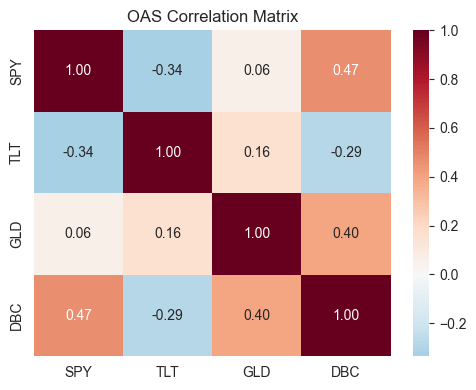

In [5]:
corr = pd.DataFrame(
    cov.values / np.outer(np.sqrt(np.diag(cov.values)), np.sqrt(np.diag(cov.values))),
    index=cov.index, columns=cov.columns,
)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax)
ax.set_title('OAS Correlation Matrix')
plt.tight_layout()
plt.show()

## Step 2 -- Project to 1-year horizon (P3 + P4)

Scale the weekly moments to an annual horizon and convert from log to simple returns.

In [6]:
from pyvallocation.utils.projection import project_mean_covariance, log2simple

ANNUALIZATION = 52
mu_h, cov_h = project_mean_covariance(mu, cov, annualization_factor=ANNUALIZATION)
mu_s, cov_s = log2simple(mu_h, cov_h)

annual = pd.DataFrame({
    'E[r] (%)': (mu_s * 100).round(2),
    'Vol (%)': (np.sqrt(np.diag(cov_s.values)) * 100).round(2),
})
print(annual)

     E[r] (%)  Vol (%)
SPY     10.91    20.79
TLT      7.28    14.87
GLD      8.73    19.48
DBC      3.27    19.98


## Step 3 -- Build multiple frontiers

Construct Mean-Variance, CVaR, and Relaxed Risk Parity frontiers on the annual simple-return moments.

In [7]:
from pyvallocation import PortfolioWrapper, plot_frontiers

wrapper_mv = PortfolioWrapper.from_moments(mu_s, cov_s)
frontier_mv = wrapper_mv.variance_frontier(num_portfolios=10)

wrapper_cvar = PortfolioWrapper.from_moments(mu_s, cov_s)
frontier_cvar = wrapper_cvar.cvar_frontier(num_portfolios=10, alpha=0.05)

wrapper_rp = PortfolioWrapper.from_moments(mu_s, cov_s)
frontier_rp = wrapper_rp.relaxed_risk_parity_frontier(
    num_portfolios=10, lambda_reg=0.0,
)

Scenario simulation is non-reproducible (no seed). Pass seed= for reproducibility.


/Users/giuliocantadori/dev/Py-vAllocation/pyvallocation/portfolioapi.py:987: RuntimeWarning: divide by zero encountered in matmul
  scenarios = rng.multivariate_normal(self.dist.mu, self.dist.cov, n_simulations)
/Users/giuliocantadori/dev/Py-vAllocation/pyvallocation/portfolioapi.py:987: RuntimeWarning: overflow encountered in matmul
  scenarios = rng.multivariate_normal(self.dist.mu, self.dist.cov, n_simulations)
/Users/giuliocantadori/dev/Py-vAllocation/pyvallocation/portfolioapi.py:987: RuntimeWarning: invalid value encountered in matmul
  scenarios = rng.multivariate_normal(self.dist.mu, self.dist.cov, n_simulations)


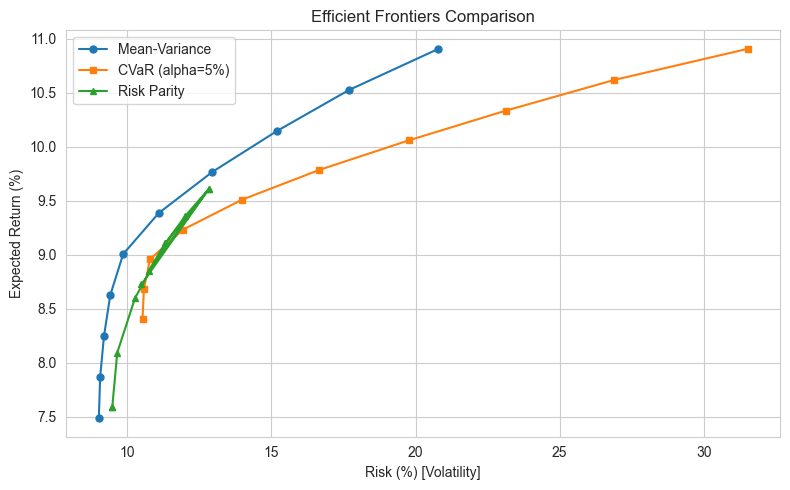

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
for frontier, label, marker in [
    (frontier_mv, 'Mean-Variance', 'o'),
    (frontier_cvar, 'CVaR (alpha=5%)', 's'),
    (frontier_rp, 'Risk Parity', '^'),
]:
    ax.plot(frontier.risks * 100, frontier.returns * 100,
            marker=marker, label=label, markersize=5)
ax.set_xlabel(f'Risk (%) [{frontier_mv.risk_measure}]')
ax.set_ylabel('Expected Return (%)')
ax.set_title('Efficient Frontiers Comparison')
ax.legend()
plt.tight_layout()
plt.show()

## Step 4 -- Select portfolios at comparable risk

Pick the 50th risk-percentile portfolio from each frontier so they sit at roughly the same risk level.

In [9]:
from pyvallocation.ensembles import risk_percentile_selections

sels = risk_percentile_selections(
    [frontier_mv, frontier_cvar, frontier_rp], percentile=0.50,
)

w_mv, r_mv, s_mv = frontier_mv.at_percentile(0.50)
w_cvar, r_cvar, s_cvar = frontier_cvar.at_percentile(0.50)
w_rp, r_rp, s_rp = frontier_rp.at_percentile(0.50)

portfolios = {'MV': w_mv, 'CVaR': w_cvar, 'RP': w_rp}

comparison = pd.DataFrame(portfolios).round(4)
print(comparison)

         MV    CVaR      RP
SPY  0.4113  0.5456  0.4765
TLT  0.4258  0.2809  0.3398
GLD  0.1629  0.1734  0.1067
DBC  0.0000  0.0000  0.0770


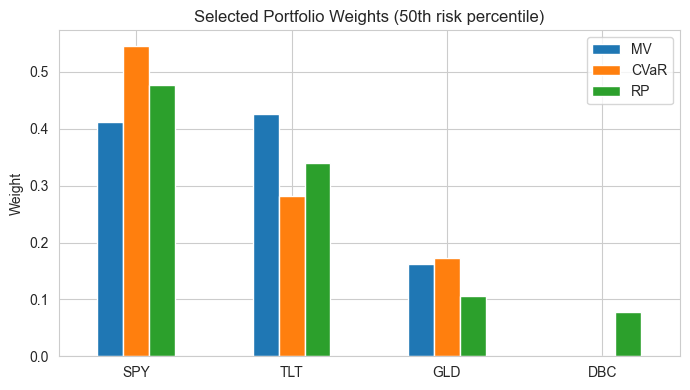

In [10]:
comparison.plot.bar(figsize=(7, 4), rot=0)
plt.ylabel('Weight')
plt.title('Selected Portfolio Weights (50th risk percentile)')
plt.tight_layout()
plt.show()

## Step 5 -- Ensemble blending

Combine the three selected portfolios via exposure stacking and simple averaging.

In [11]:
from pyvallocation.ensembles import exposure_stacking, average_exposures

samples = pd.DataFrame(portfolios)
w_stacked = exposure_stacking(samples, L=2)
w_avg = average_exposures(samples)

blend = pd.DataFrame({'Stacked': w_stacked, 'Average': w_avg}).round(4)
print(blend)

# Use stacked weights for downstream analysis
weights = np.asarray(w_stacked, dtype=float).ravel()

     Stacked  Average
SPY   0.4705   0.4778
TLT   0.3603   0.3489
GLD   0.1611   0.1477
DBC   0.0081   0.0257


## Step 6 -- Stress testing

Evaluate the stacked portfolio under nominal, decay, kernel-focus, and shock scenarios,
then project across multiple horizons.

### 6a. Nominal performance (out-of-sample weekly returns)

In [12]:
from pyvallocation.utils.performance import performance_report

report_nom = performance_report(weights, simple_ret_oos.values, confidence=0.95)
print('=== Nominal Performance (OOS weekly) ===')
print(report_nom.round(6))

=== Nominal Performance (OOS weekly) ===
mean        0.000769
stdev       0.015344
VaR95       0.023400
CVaR95      0.028934
ENS       202.000000
dtype: float64


### 6b. Exponential-decay stress (half-life = 30 weeks)

In [13]:
from pyvallocation.stress import exp_decay_stress

report_decay = exp_decay_stress(weights, simple_ret_oos.values, half_life=30)
print('=== Exponential Decay Stress (HL=30) ===')
print(report_decay.round(6))

=== Exponential Decay Stress (HL=30) ===
             return_nom  stdev_nom  VaR95_nom  CVaR95_nom  ENS_nom  \
portfolio_0    0.000769   0.015344     0.0234    0.028934    202.0   

             return_stress  stdev_stress  VaR95_stress  CVaR95_stress  \
portfolio_0       0.001794      0.014325       0.02033       0.028524   

             ENS_stress   KL_q_p  
portfolio_0  111.498157  0.59426  


### 6c. Kernel-focus stress targeting the worst volatility regime

In [14]:
from pyvallocation.stress import kernel_focus_stress

vol_proxy = simple_ret_oos.std(axis=1).rolling(12).mean().bfill()

report_kernel = kernel_focus_stress(
    weights, simple_ret_oos.values,
    focus_series=vol_proxy.values,
    target=vol_proxy.values.max(),
)
print('=== Kernel Focus Stress (high-vol regime) ===')
print(report_kernel.round(6))

=== Kernel Focus Stress (high-vol regime) ===
             return_nom  stdev_nom  VaR95_nom  CVaR95_nom  ENS_nom  \
portfolio_0    0.000769   0.015344     0.0234    0.028934    202.0   

             return_stress  stdev_stress  VaR95_stress  CVaR95_stress  \
portfolio_0      -0.009651      0.013562        0.0234        0.02553   

             ENS_stress    KL_q_p  
portfolio_0   11.952093  2.827361  


### 6d. Linear shock -- scale up returns by 1.5x with a negative mean shift

In [15]:
from pyvallocation.stress import stress_test, linear_map

shock = linear_map(scale=1.5, mean_shift=np.full(4, -0.003))
report_shock = stress_test(weights, simple_ret_oos.values, transform=shock)
print('=== Linear Shock (1.5x scale, -30 bps shift) ===')
print(report_shock.round(6))

=== Linear Shock (1.5x scale, -30 bps shift) ===
             return_nom  stdev_nom  VaR95_nom  CVaR95_nom  ENS_nom  \
portfolio_0    0.000769   0.015344     0.0234    0.028934    202.0   

             return_stress  stdev_stress  VaR95_stress  CVaR95_stress  \
portfolio_0      -0.001846      0.023017        0.0381       0.046401   

             ENS_stress  
portfolio_0       202.0  


### 6e. Multi-horizon projection

Bootstrap in-sample log-returns to 1-month, 3-month, and 6-month horizons,
reprice via `reprice_exp`, and report performance.

In [16]:
from pyvallocation.utils.projection import project_scenarios, reprice_exp

rows = []
for hw in [4, 13, 26]:
    scen = project_scenarios(
        log_ret_is, investment_horizon=hw,
        n_simulations=5000, reprice=reprice_exp,
    )
    rpt = performance_report(weights, scen.values, confidence=0.95)
    rows.append({'horizon_weeks': hw, **rpt.to_dict()})

horizon_table = pd.DataFrame(rows).set_index('horizon_weeks')
print(horizon_table.round(4))

                 mean   stdev   VaR95  CVaR95     ENS
horizon_weeks                                        
4              0.0069  0.0260  0.0340  0.0555  5000.0
13             0.0238  0.0477  0.0562  0.0823  5000.0
26             0.0488  0.0688  0.0646  0.0941  5000.0


### 6f. Path visualisation -- return distributions by horizon and portfolio

/var/folders/kd/ch5dsx357yg2zrg8f0kr0nr00000gn/T/ipykernel_72175/3603837998.py:11: RuntimeWarning: divide by zero encountered in matmul
  pnl = scen.values @ w_arr
/var/folders/kd/ch5dsx357yg2zrg8f0kr0nr00000gn/T/ipykernel_72175/3603837998.py:11: RuntimeWarning: overflow encountered in matmul
  pnl = scen.values @ w_arr
/var/folders/kd/ch5dsx357yg2zrg8f0kr0nr00000gn/T/ipykernel_72175/3603837998.py:11: RuntimeWarning: invalid value encountered in matmul
  pnl = scen.values @ w_arr
/var/folders/kd/ch5dsx357yg2zrg8f0kr0nr00000gn/T/ipykernel_72175/3603837998.py:11: RuntimeWarning: divide by zero encountered in matmul
  pnl = scen.values @ w_arr
/var/folders/kd/ch5dsx357yg2zrg8f0kr0nr00000gn/T/ipykernel_72175/3603837998.py:11: RuntimeWarning: overflow encountered in matmul
  pnl = scen.values @ w_arr
/var/folders/kd/ch5dsx357yg2zrg8f0kr0nr00000gn/T/ipykernel_72175/3603837998.py:11: RuntimeWarning: invalid value encountered in matmul
  pnl = scen.values @ w_arr
/var/folders/kd/ch5dsx357yg2zr

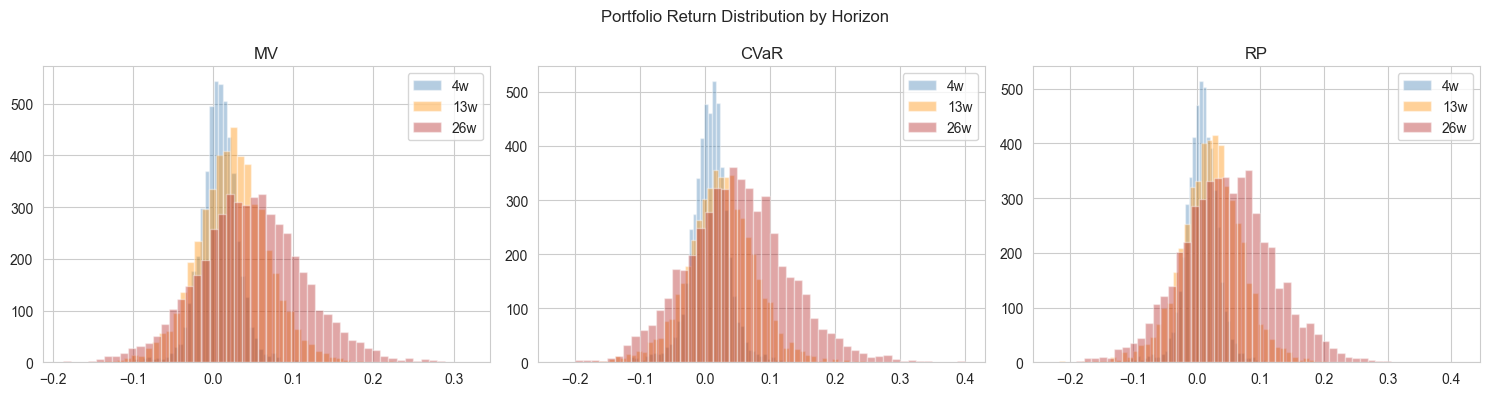

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
horizon_colors = {4: 'steelblue', 13: 'darkorange', 26: 'firebrick'}

for ax, (name, w_s) in zip(axes, portfolios.items()):
    w_arr = np.asarray(w_s, dtype=float).ravel()
    for hw, color in horizon_colors.items():
        scen = project_scenarios(
            log_ret_is, investment_horizon=hw,
            n_simulations=5000, reprice=reprice_exp,
        )
        pnl = scen.values @ w_arr
        ax.hist(pnl, bins=50, alpha=0.4, color=color, label=f'{hw}w')
    ax.set_title(name)
    ax.legend()

fig.suptitle('Portfolio Return Distribution by Horizon')
plt.tight_layout()
plt.show()

### Stress summary table

In [18]:
summary = pd.DataFrame({
    'Nominal (weekly)': report_nom,
    'Exp-Decay (HL=30)': report_decay.iloc[0],
    'Kernel Focus': report_kernel.iloc[0],
    'Linear Shock': report_shock.iloc[0],
})
print(summary.round(6))

               Nominal (weekly)  Exp-Decay (HL=30)  Kernel Focus  Linear Shock
CVaR95                 0.028934                NaN           NaN           NaN
CVaR95_nom                  NaN           0.028934      0.028934      0.028934
CVaR95_stress               NaN           0.028524      0.025530      0.046401
ENS                  202.000000                NaN           NaN           NaN
ENS_nom                     NaN         202.000000    202.000000    202.000000
ENS_stress                  NaN         111.498157     11.952093    202.000000
KL_q_p                      NaN           0.594260      2.827361           NaN
VaR95                  0.023400                NaN           NaN           NaN
VaR95_nom                   NaN           0.023400      0.023400      0.023400
VaR95_stress                NaN           0.020330      0.023400      0.038100
mean                   0.000769                NaN           NaN           NaN
return_nom                  NaN           0.000769  

## Step 7 -- Discrete allocation

Convert the stacked continuous weights into integer share counts given a $100,000 portfolio,
using the latest prices in the dataset.

In [19]:
from pyvallocation.discrete_allocation import discretize_weights

latest_prices = prices.iloc[-1]
total_value = 100_000.0

w_series = pd.Series(weights, index=log_returns.columns, name='Stacked')
result = discretize_weights(w_series, latest_prices, total_value)

print('Shares:')
for asset, count in result.shares.items():
    print(f'  {asset}: {count} shares @ ${latest_prices[asset]:.2f} = ${count * latest_prices[asset]:,.2f}')
print(f'\nLeftover cash: ${result.leftover_cash:,.2f}')
print(f'Tracking error (L1): {result.tracking_error:.4f}')

Shares:
  SPY: 81 shares @ $579.11 = $46,907.91
  TLT: 427 shares @ $84.55 = $36,102.85
  GLD: 52 shares @ $309.75 = $16,107.00
  DBC: 38 shares @ $21.41 = $813.58

Leftover cash: $68.66
Tracking error (L1): 0.0021
